# Data Wrangling

## Data Wrangling

1. Make the data accessible (Pandas)
2. Determine **schema** of the data
3. Verify **data types** and **cast**
4. Assess **missing values**, consider **imputation**
5. **Filter** the Data: Pick subsets of rows/columns
6. Save your work

> Data cleaning is approximately 80% of data science

## The Standard Stack

- Most of your code will start with:

``` python
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
```

- The `numpy` package extends python by adding numerical analysis
- `matplotlib.pyplot` adds plots
- `pandas` adds data frames
- `seaborn` adds a simpler plotting API for quick visualizations 
- `pip install package` will add `package` to your current Python environment

## (1) Dataframes

1. Load the data: `df = pd.read_csv('these_data.csv',low_memory=False)`
2. Verify data dimensions: `df.shape`
3. Verify data integrity: `df.head()`

## Data Frames

- Columns are **variables**: Features of a phenomenon of interest
    - To select a particlar variable `var`, `df[var]`
    - If you're transforming an existing variable, `df[var_transform] = transformation(df[var])`
- Rows are **observations**: Instances of a phenomenon of interest
- **Values** are the recorded numeric or categorical data associated with an observation for a given variable

> "What is an observation?" is one of the most powerful questions in data science

## (2) Schema

- The **schema** describes how the data are organized: what tables exist, what variables or columns they contain, what types those variables have, and how the tables are connected
- Data are **tabular** if there's rows of observations and columns of variables in a rectangular form
- In Pandas, `df.columns` returns the variables/schema

## (3) Variable Types and Casting

There are broadly five conceptually distinct **variable types**, supported by Pandas in a variety of **data types/`dtypes`**:

- **Numeric**:
    - Integer (`int`): Whole numbers, like $ ... , -3, -2, -1, 0, 1, 2, 3, ... $, stored by Pandas as an `int64`
    - Real-ish (`float`): Floating point numbers, like $3.14159$ or $1.4142$, stored by Pandas as a `float64`
- **Categorical**:
    - String (`str`): String variables with a fixed list of labels (e.g. color, brand, state, customer ID, year, zip code)
    - Often stored using Pandas' `category` type
- **Logical**:
    - Boolean (`bool`): Binary `True` or `False`
- Date:
    - Date (`datetime`): Date and time values
- Unstructured:
    - String (`str`): String variables without a fixed list (e.g. product reviews, doctor notes)

## Getting to Know a Variable

- Current data type, `df[var].dtype`
- Number of missing values, `df[var].isna().sum()`
- Unique values it takes, `df[var].unique()`
- Counts associated with unique values, `df[var].value_counts()`
- Histogram of the value counts, `df[var].hist( bins = 35 )`

> From this, you should be able to decide whether a given variable requires substantial cleaning

## Type-casting/Coercion

- Is the variable the right type?
- Data types are often inferred by the computer "incorrectly": A monetary value will be stored as `-$1,320.15` or a temperature as `23C`, and the computer will interpret these as text values because they include the `$` and `C`
- When we force the computer to treat a variable as a different data type, it is called **type casting** or **coercion**

## Type-casting/Coercion

- The steps in Pandas to cast a string to numeric are:

1. For variable `var`, replace the offending symbols with blanks: `df[var] = df[var].str.replace('$','')`
2. Type cast: `df[var] = pd.to_numeric( df[var], errors = 'coerce')`

- For other casting problems, you can do `df[var].astype(str)` for string or `df[var].astype(int)` for integer, etc.

## (4) Missing Values and Imputation

- The most important wrangling problem is **missing data**: Values have not been recorded for some observations
- Mishandling or misunderstanding the reasons why data are missing can create biases in subsequent analysis
- Missing data is not an inconvenience: It is information about the data gathering process
- If you must, you can "fill in the blanks" with the mean or median of a variable; this is called **imputation**


## Missing Values and Imputation

1. Determine missing values for each variable: `number_missing = df.isna().sum()`
2. Create missing value dummies: 
``` python
schema = df.columns
for var in schema:
    if df[var].isna().any():
        df[ f'{var}_NA'] = df[var].isna()
```
3. For a numeric, consider replacing missing values with medians, where desired: `df[f'{var}_imp'] = df[var].fillna( df[var].median() ) `. For a categorical, simply create a new category: `df[var] = df[var].fillna('NA')` or `df[var] = df[var].fillna('Missing')`

## (5) Filtering: Subsetting the Data

- Column filtering:
    1. Suppose `columns = [var_1, var_2, ... , var_N ]` are the variables of interest
    2. `df_cols = df[columns]` returns just the columns associated with `column`

- Row filtering:
    
    1. Suppose `row_condition` is a logical condition, like 
    >`row_condition = ( df[price]>1000 )` 
    >`row_condition = ( df[state]=='NY' )`

    2. `df_rows = df[row_condition]` returns just the observations associated with `row_condition==True`


## Filtering

- Both:
    1. Define `row_condition` and `columns`
    2. Use 
    >`df_subset = df.loc[ row_condition, columns ]`

## (6) Saving the Dataframe

- Never overwrite the original datafile: Always keep the original data for reproducibility
- A widely used and human-readable format is comma separated value: `df.to_csv( 'data_cleaned.csv', index = False )`
- A more efficient format for large or complex datasets is parquet: `df.to_parquet( 'data_cleaned.parquet', index = False )`

In [7]:
import pandas as pandas
import numpy as np

x = np.array([1, 2, 3])

print(x)

y = x ** 2

[1 2 3]


<Axes: >

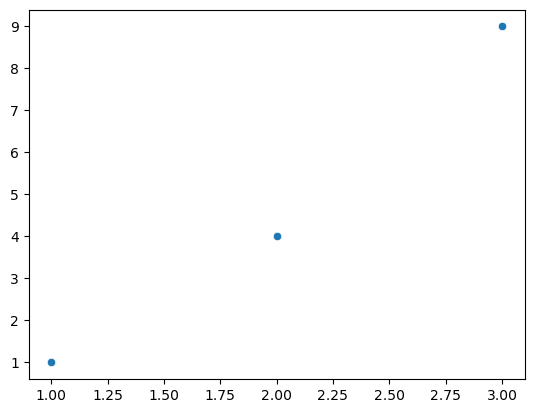

In [8]:
import seaborn as sns

sns.scatterplot( x=x, y=y)